# Hough-Only Track Analysis (Deep Extraction)

This notebook keeps only the Hough circle workflow and uses the **same core parameters** as `blob_detection_analysis.ipynb`:

- Contrast rescale percentiles: **2 to 98**
- Canny edge `sigma`: **2**
- Radius search range: **5 to 49 px** (`np.arange(5, 50, 1)`)
- `hough_circle_peaks(..., total_num_peaks=500)`

It then extracts extensive per-track information (geometry, intensity, contrast/background, edge support, overlap, neighborhood metrics), plus per-image and global summaries.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from skimage.io import imread
from skimage import exposure
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.filters import sobel

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

In [2]:
# Resolve image folder (workspace-relative first, then original absolute path fallback)
candidate_paths = [
    os.path.join(os.getcwd(), 'images'),
    r'C:\Users\Sahar\Desktop\Tecnorad internship\images'
]

image_path = None
for p in candidate_paths:
    if os.path.isdir(p):
        image_path = p
        break

if image_path is None:
    raise FileNotFoundError('Could not find images directory. Checked: ' + str(candidate_paths))

image_files = sorted(glob.glob(os.path.join(image_path, '*.bmp')))
if not image_files:
    raise FileNotFoundError(f'No .bmp files found in {image_path}')

print(f'Image directory: {image_path}')
print(f'Found {len(image_files)} images')
print('First files:', [os.path.basename(f) for f in image_files[:5]])

Image directory: c:\Users\Sahar\Desktop\Tecnorad internship\images
Found 13 images
First files: ['1.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp']


In [8]:
# Baseline (original notebook) settings
ORIG_MIN_RADIUS = 5
ORIG_MAX_RADIUS = 50
ORIG_CANNY_SIGMA = 2
ORIG_TOTAL_NUM_PEAKS = 500

# Tuned settings (to reduce saturation/duplicates while keeping the same Hough approach)
MIN_RADIUS = 6
MAX_RADIUS = 30
CANNY_SIGMA = 2
TOTAL_NUM_PEAKS = 350
MIN_CENTER_DISTANCE = 8
ACCUM_KEEP_PERCENTILE = 70
RESCALE_PCTS = (2, 98)
ANNULUS_INNER_SCALE = 1.2
ANNULUS_OUTER_SCALE = 1.6
BOUNDARY_HALF_WIDTH = 1.5

def detect_circles_hough_same_params(image, min_radius=MIN_RADIUS, max_radius=MAX_RADIUS):
    """Hough circle detection with the exact core parameters used in blob_detection_analysis.ipynb"""
    p2, p98 = np.percentile(image, RESCALE_PCTS)
    img_rescaled = exposure.rescale_intensity(image, in_range=(p2, p98))

    edges = canny(img_rescaled, sigma=CANNY_SIGMA)

    hough_radii = np.arange(min_radius, max_radius, 1)
    hough_res = hough_circle(edges, hough_radii)

    accums, cx, cy, radii = hough_circle_peaks(
        hough_res,
        hough_radii,
        total_num_peaks=TOTAL_NUM_PEAKS,
        min_xdistance=MIN_CENTER_DISTANCE,
        min_ydistance=MIN_CENTER_DISTANCE
    )

    if len(accums):
        keep_thr = np.percentile(accums, ACCUM_KEEP_PERCENTILE)
        keep = accums >= keep_thr
        accums, cx, cy, radii = accums[keep], cx[keep], cy[keep], radii[keep]

    circles = np.column_stack([cy, cx, radii]) if len(radii) else np.empty((0, 3))
    return circles, accums, edges, img_rescaled

In [9]:
def compute_track_metrics(image, img_rescaled, edges, circles, accums, image_name):
    h, w = image.shape
    grad_mag = sobel(img_rescaled)

    rows = []

    for i, ((y, x, r), accum) in enumerate(zip(circles, accums), start=1):
        yy, xx = np.ogrid[:h, :w]
        dist = np.sqrt((yy - y) ** 2 + (xx - x) ** 2)

        inner_mask = dist <= r
        annulus_mask = (dist > (ANNULUS_INNER_SCALE * r)) & (dist <= (ANNULUS_OUTER_SCALE * r))
        boundary_mask = np.abs(dist - r) <= BOUNDARY_HALF_WIDTH

        inner_vals = image[inner_mask]
        annulus_vals = image[annulus_mask] if np.any(annulus_mask) else np.array([])

        mean_in = float(np.mean(inner_vals)) if inner_vals.size else np.nan
        std_in = float(np.std(inner_vals)) if inner_vals.size else np.nan
        median_in = float(np.median(inner_vals)) if inner_vals.size else np.nan
        min_in = float(np.min(inner_vals)) if inner_vals.size else np.nan
        max_in = float(np.max(inner_vals)) if inner_vals.size else np.nan
        sum_in = float(np.sum(inner_vals)) if inner_vals.size else np.nan

        mean_bg = float(np.mean(annulus_vals)) if annulus_vals.size else np.nan
        std_bg = float(np.std(annulus_vals)) if annulus_vals.size else np.nan

        local_contrast = mean_in - mean_bg if (not np.isnan(mean_in) and not np.isnan(mean_bg)) else np.nan
        snr_local = ((mean_in - mean_bg) / (std_bg + 1e-12)) if (not np.isnan(mean_bg) and not np.isnan(std_bg)) else np.nan

        edge_support = float(np.mean(edges[boundary_mask])) if np.any(boundary_mask) else np.nan
        grad_boundary_mean = float(np.mean(grad_mag[boundary_mask])) if np.any(boundary_mask) else np.nan

        area_px = float(np.pi * r ** 2)
        perimeter_px = float(2 * np.pi * r)
        diameter_px = float(2 * r)

        x_min = float(max(0, x - r))
        x_max = float(min(w - 1, x + r))
        y_min = float(max(0, y - r))
        y_max = float(min(h - 1, y + r))

        touches_border = bool((x - r) < 0 or (x + r) >= w or (y - r) < 0 or (y + r) >= h)

        rows.append({
            'image': image_name,
            'track_id': i,
            'center_y': float(y),
            'center_x': float(x),
            'center_y_norm': float(y / max(h - 1, 1)),
            'center_x_norm': float(x / max(w - 1, 1)),
            'radius_px': float(r),
            'diameter_px': diameter_px,
            'area_px2': area_px,
            'perimeter_px': perimeter_px,
            'accumulator_score': float(accum),
            'bbox_x_min': x_min,
            'bbox_x_max': x_max,
            'bbox_y_min': y_min,
            'bbox_y_max': y_max,
            'touches_border': touches_border,
            'mean_intensity_inside': mean_in,
            'std_intensity_inside': std_in,
            'median_intensity_inside': median_in,
            'min_intensity_inside': min_in,
            'max_intensity_inside': max_in,
            'integrated_intensity_inside': sum_in,
            'mean_intensity_annulus_bg': mean_bg,
            'std_intensity_annulus_bg': std_bg,
            'local_contrast_inside_minus_bg': local_contrast,
            'local_snr': snr_local,
            'edge_support_ratio': edge_support,
            'mean_gradient_on_boundary': grad_boundary_mean,
            'image_height': int(h),
            'image_width': int(w)
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        coords = df[['center_y', 'center_x']].to_numpy()
        radii = df['radius_px'].to_numpy()

        dmat = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
        np.fill_diagonal(dmat, np.inf)

        nn_dist = np.min(dmat, axis=1)
        overlap_counts = []
        max_overlap_ratio = []

        for idx in range(len(df)):
            overlap_amount = (radii[idx] + radii) - dmat[idx]
            overlap_amount[idx] = -np.inf
            overlaps = overlap_amount > 0
            overlap_counts.append(int(np.sum(overlaps)))

            if np.any(overlaps):
                ratio = overlap_amount[overlaps] / (radii[idx] + radii[overlaps])
                max_overlap_ratio.append(float(np.max(ratio)))
            else:
                max_overlap_ratio.append(0.0)

        df['nearest_neighbor_distance_px'] = nn_dist
        df['overlap_count'] = overlap_counts
        df['max_overlap_ratio'] = max_overlap_ratio
        df['isolated_track'] = df['overlap_count'] == 0

    return df

In [10]:
all_track_tables = []
per_image_summary = []
debug_views = {}

for img_path in image_files:
    image = imread(img_path, as_gray=True)
    img_name = os.path.basename(img_path)

    circles, accums, edges, img_rescaled = detect_circles_hough_same_params(image)
    track_df = compute_track_metrics(image, img_rescaled, edges, circles, accums, img_name)

    all_track_tables.append(track_df)

    if not track_df.empty:
        summary = {
            'image': img_name,
            'count': int(len(track_df)),
            'min_radius_px': float(track_df['radius_px'].min()),
            'max_radius_px': float(track_df['radius_px'].max()),
            'mean_radius_px': float(track_df['radius_px'].mean()),
            'median_radius_px': float(track_df['radius_px'].median()),
            'std_radius_px': float(track_df['radius_px'].std(ddof=0)),
            'min_area_px2': float(track_df['area_px2'].min()),
            'max_area_px2': float(track_df['area_px2'].max()),
            'mean_area_px2': float(track_df['area_px2'].mean()),
            'mean_local_contrast': float(track_df['local_contrast_inside_minus_bg'].mean()),
            'mean_edge_support': float(track_df['edge_support_ratio'].mean()),
            'isolated_ratio': float(track_df['isolated_track'].mean()),
            'touches_border_ratio': float(track_df['touches_border'].mean())
        }
    else:
        summary = {
            'image': img_name,
            'count': 0,
            'min_radius_px': np.nan,
            'max_radius_px': np.nan,
            'mean_radius_px': np.nan,
            'median_radius_px': np.nan,
            'std_radius_px': np.nan,
            'min_area_px2': np.nan,
            'max_area_px2': np.nan,
            'mean_area_px2': np.nan,
            'mean_local_contrast': np.nan,
            'mean_edge_support': np.nan,
            'isolated_ratio': np.nan,
            'touches_border_ratio': np.nan
        }

    per_image_summary.append(summary)
    debug_views[img_name] = (image, circles)

tracks_df = pd.concat(all_track_tables, ignore_index=True) if all_track_tables else pd.DataFrame()
summary_df = pd.DataFrame(per_image_summary).sort_values('image').reset_index(drop=True)

print(f'Total detected tracks: {len(tracks_df):,}')
print(f'Images analyzed: {len(summary_df)}')
summary_df.head(10)

Total detected tracks: 1,091
Images analyzed: 13


,image,count,min_radius_px,max_radius_px,mean_radius_px,median_radius_px,std_radius_px,min_area_px2,max_area_px2,mean_area_px2,mean_local_contrast,mean_edge_support,isolated_ratio,touches_border_ratio
0,1.bmp,70,6.0,24.0,15.600000,16.0,6.275576,113.097336,1809.557368,888.262883,-146.616577,0.301881,0.757143,0.000000
1,10.bmp,110,6.0,24.0,7.627273,6.0,3.642824,113.097336,1809.557368,224.452515,-45.287516,0.321242,0.909091,0.000000
2,11.bmp,111,6.0,24.0,7.954955,6.0,4.243463,113.097336,1809.557368,255.374689,-58.148408,0.332861,0.909910,0.000000
3,12.bmp,106,6.0,24.0,10.405660,7.0,6.267283,113.097336,1809.557368,463.562742,-53.074841,0.312979,0.792453,0.009434
4,13.bmp,71,6.0,24.0,15.338028,16.0,5.985766,113.097336,1809.557368,851.637096,-180.981424,0.300467,0.802817,0.000000
5,2.bmp,89,6.0,24.0,13.224719,13.0,6.040598,113.097336,1809.557368,664.076209,-139.263376,0.269338,0.707865,0.011236
6,3.bmp,74,6.0,24.0,14.905405,16.0,6.100884,113.097336,1809.557368,814.903662,-170.480575,0.294970,0.837838,0.027027
7,4.bmp,67,6.0,24.0,15.522388,17.0,5.875215,113.097336,1809.557368,865.391552,-179.747586,0.302242,0.820896,0.059701
8,5.bmp,57,6.0,24.0,15.754386,16.0,5.679389,113.097336,1809.557368,881.078950,-179.074027,0.313673,0.929825,0.035088
9,6.bmp,86,6.0,23.0,13.906977,14.0,6.395180,113.097336,1661.902514,736.082465,-157.703117,0.306079,0.732558,0.011628


In [11]:
print('Per-image summary (first 20):')
display(summary_df.head(20))

if not tracks_df.empty:
    print('Detailed tracks sample:')
    display(tracks_df.head(20))

    print('Top 20 largest tracks by area:')
    display(tracks_df.sort_values('area_px2', ascending=False).head(20))

    global_stats = {
        'total_tracks': int(len(tracks_df)),
        'global_min_radius_px': float(tracks_df['radius_px'].min()),
        'global_max_radius_px': float(tracks_df['radius_px'].max()),
        'global_mean_radius_px': float(tracks_df['radius_px'].mean()),
        'global_median_radius_px': float(tracks_df['radius_px'].median()),
        'global_min_area_px2': float(tracks_df['area_px2'].min()),
        'global_max_area_px2': float(tracks_df['area_px2'].max()),
        'global_mean_area_px2': float(tracks_df['area_px2'].mean()),
        'global_mean_contrast': float(tracks_df['local_contrast_inside_minus_bg'].mean()),
        'global_mean_edge_support': float(tracks_df['edge_support_ratio'].mean())
    }

    print('Global statistics:')
    for k, v in global_stats.items():
        print(f'  {k}: {v}')

Per-image summary (first 20):


,image,count,min_radius_px,max_radius_px,mean_radius_px,median_radius_px,std_radius_px,min_area_px2,max_area_px2,mean_area_px2,mean_local_contrast,mean_edge_support,isolated_ratio,touches_border_ratio
0,1.bmp,70,6.0,24.0,15.600000,16.0,6.275576,113.097336,1809.557368,888.262883,-146.616577,0.301881,0.757143,0.000000
1,10.bmp,110,6.0,24.0,7.627273,6.0,3.642824,113.097336,1809.557368,224.452515,-45.287516,0.321242,0.909091,0.000000
2,11.bmp,111,6.0,24.0,7.954955,6.0,4.243463,113.097336,1809.557368,255.374689,-58.148408,0.332861,0.909910,0.000000
3,12.bmp,106,6.0,24.0,10.405660,7.0,6.267283,113.097336,1809.557368,463.562742,-53.074841,0.312979,0.792453,0.009434
4,13.bmp,71,6.0,24.0,15.338028,16.0,5.985766,113.097336,1809.557368,851.637096,-180.981424,0.300467,0.802817,0.000000
5,2.bmp,89,6.0,24.0,13.224719,13.0,6.040598,113.097336,1809.557368,664.076209,-139.263376,0.269338,0.707865,0.011236
6,3.bmp,74,6.0,24.0,14.905405,16.0,6.100884,113.097336,1809.557368,814.903662,-170.480575,0.294970,0.837838,0.027027
7,4.bmp,67,6.0,24.0,15.522388,17.0,5.875215,113.097336,1809.557368,865.391552,-179.747586,0.302242,0.820896,0.059701
8,5.bmp,57,6.0,24.0,15.754386,16.0,5.679389,113.097336,1809.557368,881.078950,-179.074027,0.313673,0.929825,0.035088
9,6.bmp,86,6.0,23.0,13.906977,14.0,6.395180,113.097336,1661.902514,736.082465,-157.703117,0.306079,0.732558,0.011628


Detailed tracks sample:


,image,track_id,center_y,center_x,center_y_norm,center_x_norm,radius_px,diameter_px,area_px2,perimeter_px,accumulator_score,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,touches_border,mean_intensity_inside,std_intensity_inside,median_intensity_inside,min_intensity_inside,max_intensity_inside,integrated_intensity_inside,mean_intensity_annulus_bg,std_intensity_annulus_bg,local_contrast_inside_minus_bg,local_snr,edge_support_ratio,mean_gradient_on_boundary,image_height,image_width,nearest_neighbor_distance_px,overlap_count,max_overlap_ratio,isolated_track
0,1.bmp,1,706.0,1082.0,0.736184,0.845973,20.0,40.0,1256.637061,125.663706,0.866667,1062.0,1102.0,686.0,726.0,False,36.242641,43.981219,15.0,7.0,255.0,45557.0,222.383475,3.584214,-186.140833,-51.933513,0.395161,0.299390,960,1280,57.008771,0,0.000000,True
1,1.bmp,2,159.0,572.0,0.165798,0.447224,24.0,48.0,1809.557368,150.796447,0.847222,548.0,596.0,135.0,183.0,False,24.221974,33.585094,9.0,4.0,237.0,43430.0,219.678782,3.203627,-195.456808,-61.011107,0.375000,0.269854,960,1280,106.531685,0,0.000000,True
2,1.bmp,3,920.0,156.0,0.959333,0.121970,23.0,46.0,1661.902514,144.513262,0.794118,133.0,179.0,897.0,943.0,False,20.418028,25.180608,10.0,5.0,203.0,33751.0,182.194742,55.097282,-161.776715,-2.936201,0.394860,0.233809,960,1280,48.373546,0,0.000000,True
3,1.bmp,4,550.0,714.0,0.573514,0.558249,7.0,14.0,153.938040,43.982297,0.750000,707.0,721.0,543.0,557.0,False,108.302013,30.713158,111.0,27.0,173.0,16137.0,158.677778,92.779347,-50.375764,-0.542963,0.351562,0.206157,960,1280,28.017851,1,0.066072,False
4,1.bmp,5,405.0,77.0,0.422315,0.060203,23.0,46.0,1661.902514,144.513262,0.750000,54.0,100.0,382.0,428.0,False,30.431942,38.269838,13.0,6.0,253.0,50304.0,219.253755,3.624175,-188.821813,-52.100637,0.383178,0.276439,960,1280,87.281155,0,0.000000,True
5,1.bmp,6,694.0,1190.0,0.723670,0.930414,23.0,46.0,1661.902514,144.513262,0.735294,1167.0,1213.0,671.0,717.0,False,24.888082,32.452117,11.0,6.0,227.0,41140.0,217.884120,19.184486,-192.996038,-10.060006,0.385514,0.271449,960,1280,56.639209,0,0.000000,True
6,1.bmp,7,61.0,761.0,0.063608,0.594996,8.0,16.0,201.061930,50.265482,0.729167,753.0,769.0,53.0,69.0,False,42.197970,23.880974,36.0,14.0,136.0,8313.0,217.120370,15.381999,-174.922401,-11.371890,0.378205,0.295118,960,1280,64.031242,0,0.000000,True
7,1.bmp,8,292.0,229.0,0.304484,0.179046,19.0,38.0,1134.114948,119.380521,0.705357,210.0,248.0,273.0,311.0,False,21.441098,26.431862,10.0,5.0,155.0,24207.0,201.814263,50.981134,-180.373165,-3.538038,0.402941,0.268582,960,1280,35.383612,0,0.000000,True
8,1.bmp,9,469.0,1098.0,0.489051,0.858483,24.0,48.0,1809.557368,150.796447,0.701389,1074.0,1122.0,445.0,493.0,False,27.636921,36.516899,10.0,5.0,233.0,49553.0,221.065815,3.045430,-193.428894,-63.514467,0.361842,0.269398,960,1280,79.699435,0,0.000000,True
9,1.bmp,10,622.0,854.0,0.648592,0.667709,23.0,46.0,1661.902514,144.513262,0.691176,831.0,877.0,599.0,645.0,False,20.310950,30.099414,8.0,4.0,232.0,33574.0,220.726931,3.440482,-200.415982,-58.252303,0.399533,0.262108,960,1280,118.595953,0,0.000000,True


Top 20 largest tracks by area:


,image,track_id,center_y,center_x,center_y_norm,center_x_norm,radius_px,diameter_px,area_px2,perimeter_px,accumulator_score,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,touches_border,mean_intensity_inside,std_intensity_inside,median_intensity_inside,min_intensity_inside,max_intensity_inside,integrated_intensity_inside,mean_intensity_annulus_bg,std_intensity_annulus_bg,local_contrast_inside_minus_bg,local_snr,edge_support_ratio,mean_gradient_on_boundary,image_height,image_width,nearest_neighbor_distance_px,overlap_count,max_overlap_ratio,isolated_track
1,1.bmp,2,159.0,572.0,0.165798,0.447224,24.0,48.0,1809.557368,150.796447,0.847222,548.0,596.0,135.0,183.0,False,24.221974,33.585094,9.0,4.0,237.0,43430.0,219.678782,3.203627,-195.456808,-6.101111e+01,0.375000,0.269854,960,1280,106.531685,0,0.000000,True
8,1.bmp,9,469.0,1098.0,0.489051,0.858483,24.0,48.0,1809.557368,150.796447,0.701389,1074.0,1122.0,445.0,493.0,False,27.636921,36.516899,10.0,5.0,233.0,49553.0,221.065815,3.045430,-193.428894,-6.351447e+01,0.361842,0.269398,960,1280,79.699435,0,0.000000,True
315,12.bmp,25,61.0,168.0,0.063608,0.131353,24.0,48.0,1809.557368,150.796447,0.590278,144.0,192.0,37.0,85.0,False,25.496933,31.856362,11.0,6.0,224.0,45716.0,212.072200,87.342399,-186.575268,-2.136136e+00,0.278509,0.230969,960,1280,71.421285,0,0.000000,True
386,12.bmp,96,323.0,532.0,0.336809,0.415950,24.0,48.0,1809.557368,150.796447,0.500000,508.0,556.0,299.0,347.0,False,38.025098,44.178729,18.0,6.0,244.0,68179.0,141.970039,115.416418,-103.944942,-9.006079e-01,0.304825,0.194709,960,1280,58.008620,0,0.000000,True
387,12.bmp,97,382.0,142.0,0.398332,0.111024,24.0,48.0,1809.557368,150.796447,0.493056,118.0,166.0,358.0,406.0,False,34.108756,44.068368,14.0,7.0,255.0,61157.0,212.604617,76.260587,-178.495861,-2.340604e+00,0.254386,0.210896,960,1280,36.769553,0,0.000000,True
398,13.bmp,2,643.0,671.0,0.670490,0.524629,24.0,48.0,1809.557368,150.796447,0.847222,647.0,695.0,619.0,667.0,False,25.369214,34.092780,10.0,6.0,239.0,45487.0,242.653242,48.278707,-217.284028,-4.500618e+00,0.383772,0.328257,960,1280,48.166378,0,0.000000,True
399,13.bmp,3,139.0,476.0,0.144943,0.372166,24.0,48.0,1809.557368,150.796447,0.833333,452.0,500.0,115.0,163.0,False,25.755717,33.124695,11.0,6.0,222.0,46180.0,253.161591,16.449659,-227.405875,-1.382435e+01,0.379386,0.313802,960,1280,134.350288,0,0.000000,True
402,13.bmp,6,881.0,319.0,0.918665,0.249414,24.0,48.0,1809.557368,150.796447,0.791667,295.0,343.0,857.0,905.0,False,29.034579,33.314083,13.0,8.0,227.0,52059.0,254.996562,0.058535,-225.961983,-3.860318e+03,0.390351,0.285313,960,1280,79.056942,0,0.000000,True
41,1.bmp,42,121.0,328.0,0.126173,0.256450,24.0,48.0,1809.557368,150.796447,0.493056,304.0,352.0,97.0,145.0,False,25.026213,33.596136,10.0,5.0,234.0,44872.0,172.634086,80.256595,-147.607873,-1.839199e+00,0.293860,0.191726,960,1280,30.000000,2,0.253190,False
408,13.bmp,12,868.0,532.0,0.905109,0.415950,24.0,48.0,1809.557368,150.796447,0.715278,508.0,556.0,844.0,892.0,False,28.116007,38.618689,10.0,5.0,229.0,50412.0,214.458251,87.094397,-186.342245,-2.139543e+00,0.313596,0.286328,960,1280,40.000000,1,0.111111,False


Global statistics:
  total_tracks: 1091
  global_min_radius_px: 6.0
  global_max_radius_px: 24.0
  global_mean_radius_px: 12.701191567369387
  global_median_radius_px: 11.0
  global_min_area_px2: 113.09733552923255
  global_max_area_px2: 1809.5573684677208
  global_mean_area_px2: 633.3087965920844
  global_mean_contrast: -126.99024682893429
  global_mean_edge_support: 0.3021684038785419


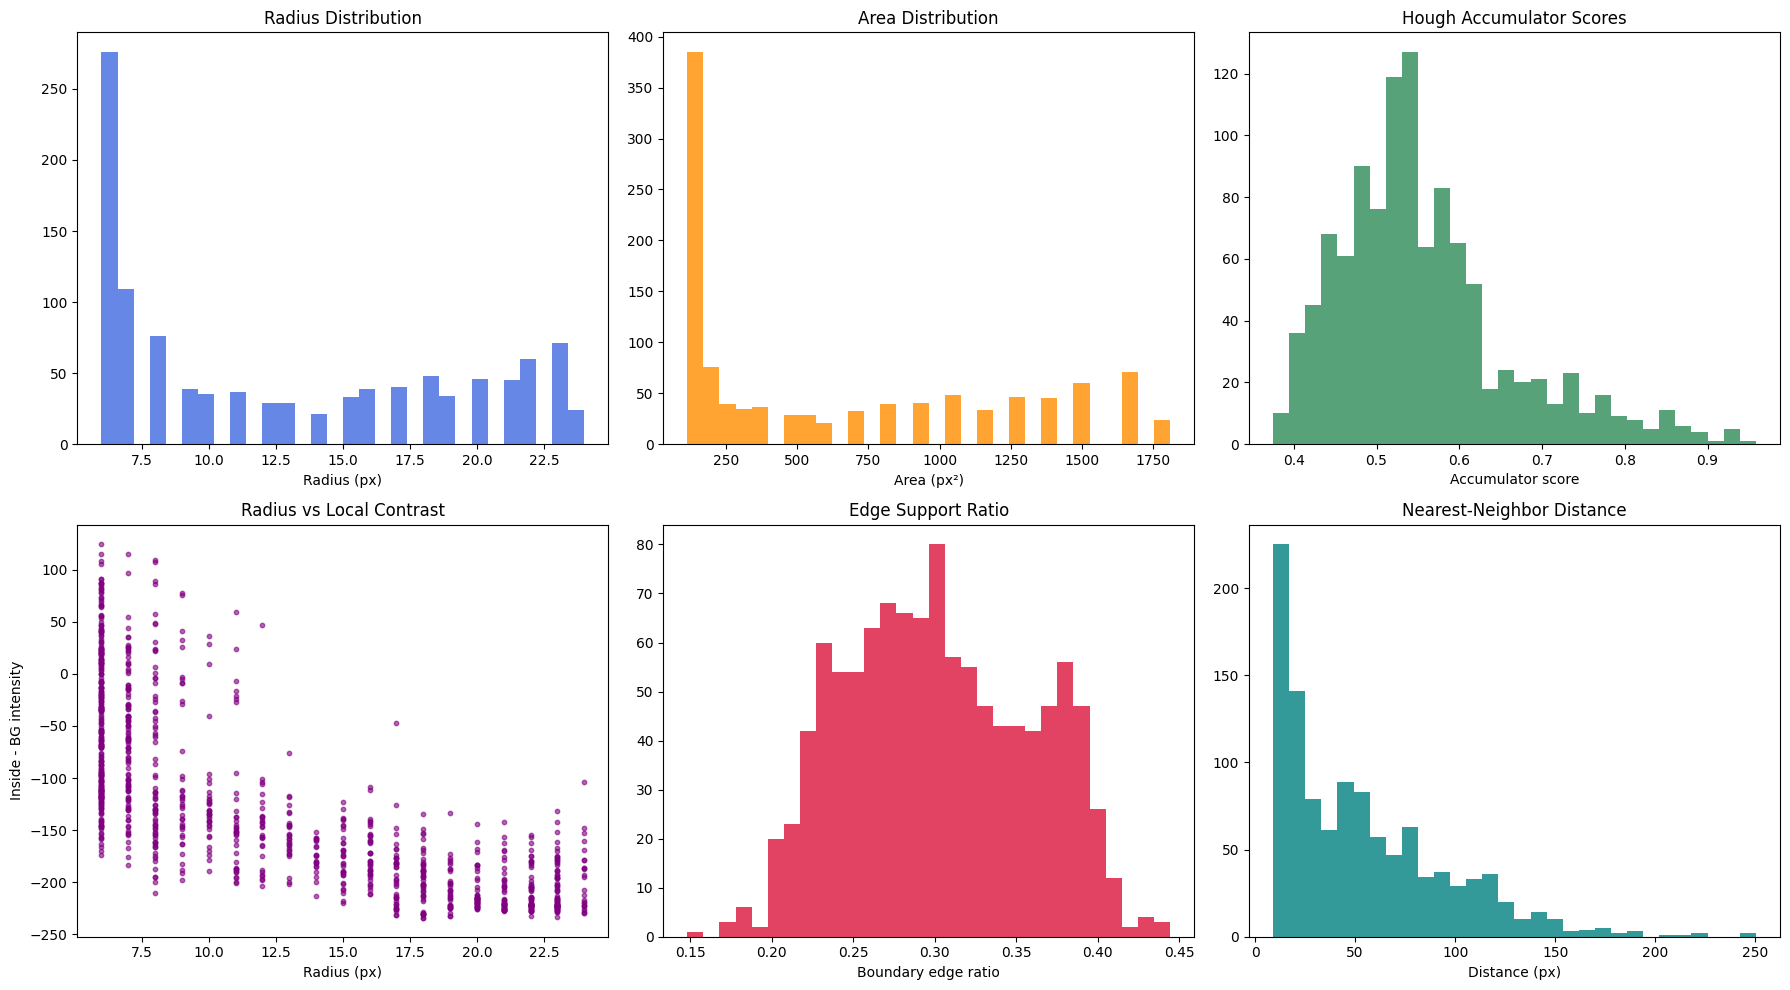

In [12]:
if not tracks_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].hist(tracks_df['radius_px'], bins=30, color='royalblue', alpha=0.8)
    axes[0, 0].set_title('Radius Distribution')
    axes[0, 0].set_xlabel('Radius (px)')

    axes[0, 1].hist(tracks_df['area_px2'], bins=30, color='darkorange', alpha=0.8)
    axes[0, 1].set_title('Area Distribution')
    axes[0, 1].set_xlabel('Area (px²)')

    axes[0, 2].hist(tracks_df['accumulator_score'], bins=30, color='seagreen', alpha=0.8)
    axes[0, 2].set_title('Hough Accumulator Scores')
    axes[0, 2].set_xlabel('Accumulator score')

    axes[1, 0].scatter(
        tracks_df['radius_px'],
        tracks_df['local_contrast_inside_minus_bg'],
        s=10, alpha=0.6, color='purple'
    )
    axes[1, 0].set_title('Radius vs Local Contrast')
    axes[1, 0].set_xlabel('Radius (px)')
    axes[1, 0].set_ylabel('Inside - BG intensity')

    axes[1, 1].hist(tracks_df['edge_support_ratio'].dropna(), bins=30, color='crimson', alpha=0.8)
    axes[1, 1].set_title('Edge Support Ratio')
    axes[1, 1].set_xlabel('Boundary edge ratio')

    axes[1, 2].hist(tracks_df['nearest_neighbor_distance_px'].dropna(), bins=30, color='teal', alpha=0.8)
    axes[1, 2].set_title('Nearest-Neighbor Distance')
    axes[1, 2].set_xlabel('Distance (px)')

    plt.tight_layout()
    plt.show()

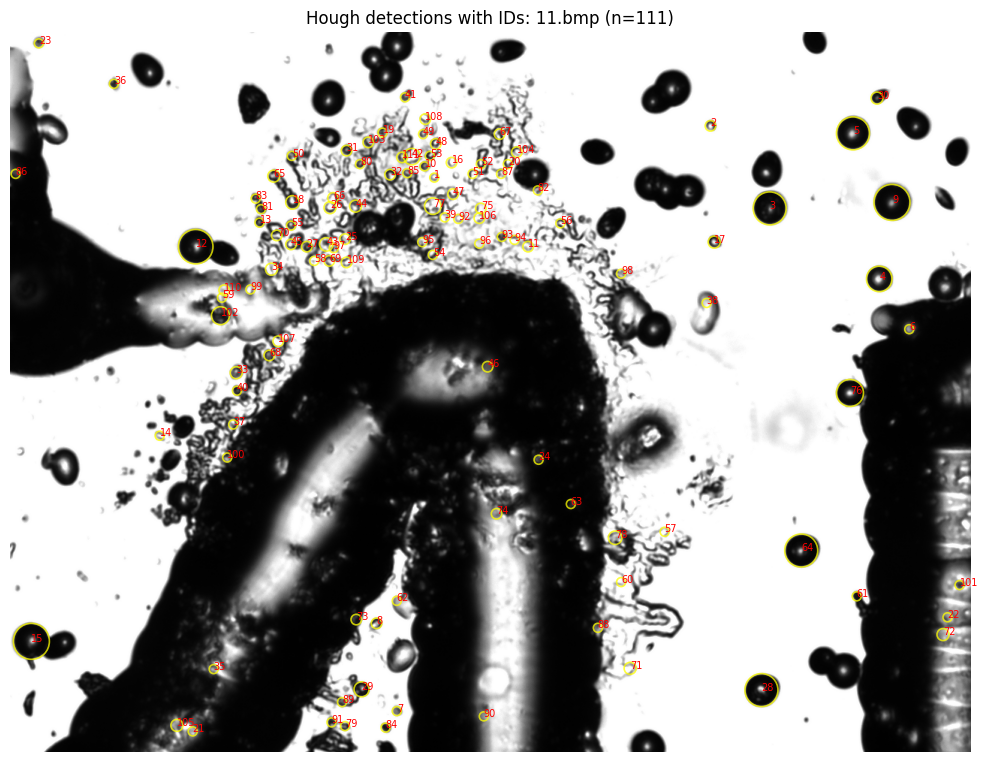

In [13]:
# Visualize one image with Hough circles + IDs
sample_name = summary_df.sort_values('count', ascending=False)['image'].iloc[0]
sample_path = [p for p in image_files if os.path.basename(p) == sample_name][0]
sample_img = imread(sample_path, as_gray=True)
sample_tracks = tracks_df[tracks_df['image'] == sample_name].copy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(sample_img, cmap='gray')
ax.set_title(f'Hough detections with IDs: {sample_name} (n={len(sample_tracks)})')

for _, row in sample_tracks.iterrows():
    c = Circle((row['center_x'], row['center_y']), row['radius_px'], color='yellow', fill=False, linewidth=1.2, alpha=0.75)
    ax.add_patch(c)
    ax.text(row['center_x'], row['center_y'], str(int(row['track_id'])), color='red', fontsize=7)

ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Save outputs for downstream usage
tracks_out = os.path.join(os.getcwd(), 'report_images', 'hough_tracks_detailed.csv')
summary_out = os.path.join(os.getcwd(), 'report_images', 'hough_tracks_summary.csv')

os.makedirs(os.path.dirname(tracks_out), exist_ok=True)
tracks_df.to_csv(tracks_out, index=False)
summary_df.to_csv(summary_out, index=False)

print('Saved detailed tracks to:', tracks_out)
print('Saved per-image summary to:', summary_out)

Saved detailed tracks to: c:\Users\Sahar\Desktop\Tecnorad internship\report_images\hough_tracks_detailed.csv
Saved per-image summary to: c:\Users\Sahar\Desktop\Tecnorad internship\report_images\hough_tracks_summary.csv
